# Mutual Fund 1-Year Return Prediction

## Introduction

Mutual funds are among the fastest-growing investment instruments in India, offering diversification and professional portfolio management. With the increasing availability of large-scale financial data, data analytics plays a crucial role in identifying performance trends and enabling data-driven investment decisions.

This project leverages Exploratory Data Analysis (EDA) and supervised Machine Learning techniques to analyze historical Indian mutual fund data and develop a predictive model for estimating 1-Year fund returns.

# Problem Statement

The objective of this project is to predict the 1-Year Return of Indian Mutual Funds using historical performance indicators, risk metrics, and fund characteristics. This problem is formulated as a supervised regression task, where the model learns patterns from past data to estimate future returns.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/Mutual Fund Dataset 2025.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.columns.tolist()

['AUM(in Rs. cr)',
 'ExpenseRatio (%)',
 'NAV',
 '52 WeekHigh (NAV)',
 '52 WeekLow (NAV)',
 'Return (%)1 mo',
 'Return (%)3 mo',
 'Return (%)6 mo',
 'Return (%)1 yr',
 'Return (%)2 yrs',
 'Return (%)3 yrs',
 'Return (%)5 yrs',
 'Turnover Ratio (%)',
 'No. ofStocks',
 'Avg. Market Cap(in Rs. cr)',
 'Large Cap(%)',
 'Mid Cap(%)',
 'Small Cap(%)',
 'Alpha',
 'Sharpe',
 'Sortino',
 'Beta',
 'Standard Deviation']

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns.tolist()

['AUM(in Rs. cr)',
 'ExpenseRatio (%)',
 'NAV',
 '52 WeekHigh (NAV)',
 '52 WeekLow (NAV)',
 'Return (%)1 mo',
 'Return (%)3 mo',
 'Return (%)6 mo',
 'Return (%)1 yr',
 'Return (%)2 yrs',
 'Return (%)3 yrs',
 'Return (%)5 yrs',
 'Turnover Ratio (%)',
 'No. ofStocks',
 'Avg. Market Cap(in Rs. cr)',
 'Large Cap(%)',
 'Mid Cap(%)',
 'Small Cap(%)',
 'Alpha',
 'Sharpe',
 'Sortino',
 'Beta',
 'Standard Deviation']

In [ ]:
df.drop(columns=[
    'Funds',
    'Fund Manager',
    'Category',
    'Benchmark Index',
    'Exit_load_Remarks',
    'Fund Type',
    'Inception Date',
    'Highest Sector',
    'classification',
    'RupeeVestRating',
    'Return (%)10 yrs',
    'Avg. Maturity(in yrs)',
    'Mod. Duration(in yrs)',
    'Yield To Maturity (%)'
], errors='ignore', inplace=True)

In [ ]:
# Drop rows where target is missing
df = df.dropna(subset=['Return (%)1 yr'])

# Fill remaining numeric missing values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Final check
df.isnull().sum().sum()

np.int64(0)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = df.drop('Return (%)1 yr', axis=1)
y = df['Return (%)1 yr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9743568145608231


In [ ]:
df.to_excel("mutual_fund_cleaned.xlsx", index=False)

from google.colab import files
files.download("mutual_fund_cleaned.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = pd.read_csv("Mutual Fund Dataset 2025.csv")
df.head()

,Funds,Fund Manager,Category,RupeeVestRating,AUM(in Rs. cr),ExpenseRatio (%),Fund Type,Inception Date,Benchmark Index,NAV,...,Avg. Maturity(in yrs),Mod. Duration(in yrs),Yield To Maturity (%),Alpha,Sharpe,Sortino,Beta,Standard Deviation,classification,Exit_load_Remarks
0,360 ONE Balanced Hybrid Fund-Reg(G),Mayur Patel,HY-EQ,Unrated,860.1,1.94,Open Ended,25-Sep-23,NIFTY 50 Hybrid Composite Debt 50:50 Index,12.45,...,2.93,-,7.39,8.27,1.58,2.28,1.2,7.5,Hybrid : Equity Oriented,Nil upto 10% of units and 1% for remaining uni...
1,360 ONE Dynamic Bond Fund-Reg(G),Milan Mody,DT-DYN,2,737.5,0.52,Open Ended,24-Jun-13,CRISIL Dynamic Bond Index,21.5,...,6.85,-,7.35,3.5,3.72,6.7,0.64,1.45,Debt : Dynamic Bond,Nil
2,360 ONE ELSS Tax Saver Nifty 50 Index Fund-Reg(G),Parijat Garg,EQ-ELSS,Unrated,75.8,0.52,Open Ended,28-Dec-22,NIFTY 50 - TRI,13.45,...,-,-,-,1.51,0.47,0.71,0.99,13.9,Equity : Tax Saving (ELSS),Nil
3,360 ONE Flexicap Fund-Reg(G),Mayur Patel,EQ-FLEX,Unrated,1254.2,2.08,Open Ended,30-Jun-23,BSE 500 - TRI,15.33,...,-,-,-,16.98,1.4,2.02,0.92,15.45,Equity : Flexi Cap,1% on or before 365D Nil after 365D
4,360 ONE Focused Equity Fund-Reg(G),Mayur Patel,EQ-MLC,4,7305,1.78,Open Ended,30-Oct-14,BSE 500 - TRI,46.19,...,-,-,-,6.25,0.71,1,1.02,16.03,Equity : Multi Cap,1% on or before 12M


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

Shape: (1797, 37)

Missing Values:
 Funds                           0
Fund Manager                    0
Category                        0
RupeeVestRating                 0
AUM(in Rs. cr)                  0
ExpenseRatio (%)                0
Fund Type                       0
Inception Date                  0
Benchmark Index                 1
NAV                             0
52 WeekHigh (NAV)               0
52 WeekLow (NAV)                0
Return (%)1 mo                  0
Return (%)3 mo                  0
Return (%)6 mo                  0
Return (%)1 yr                  0
Return (%)2 yrs                 0
Return (%)3 yrs                 0
Return (%)5 yrs                 0
Return (%)10 yrs                0
Turnover Ratio (%)              0
No. ofStocks                    0
Avg. Market Cap(in Rs. cr)      0
Large Cap(%)                    0
Mid Cap(%)                      0
Small Cap(%)                    0
Highest Sector                  0
Avg. Maturity(in yrs)           0
Mod. Duratio

In [ ]:
df_numeric = df.select_dtypes(include=np.number)

In [ ]:
df_numeric = df_numeric.replace("-", np.nan)
df_numeric = df_numeric.dropna()

In [ ]:
print("Final Shape:", df_numeric.shape)

Final Shape: (1797, 0)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
print(df_numeric.shape)

(1797, 0)


In [ ]:
# 1️⃣ Clean column names
df.columns = df.columns.str.strip()

# 2️⃣ Replace common non-numeric symbols
df = df.replace("%", "", regex=True)
df = df.replace(",", "", regex=True)
df = df.replace("-", np.nan)

# 3️⃣ Convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4️⃣ Now select numeric columns
df_numeric = df.select_dtypes(include=np.number)

# 5️⃣ Drop rows only where target is missing
df_numeric = df_numeric.dropna(subset=["Return (%)1 yr"])

print("Final shape after proper cleaning:", df_numeric.shape)
df_numeric.head()

Final shape after proper cleaning: (1546, 37)


,Funds,Fund Manager,Category,RupeeVestRating,AUM(in Rs. cr),ExpenseRatio (%),Fund Type,Inception Date,Benchmark Index,NAV,...,Avg. Maturity(in yrs),Mod. Duration(in yrs),Yield To Maturity (%),Alpha,Sharpe,Sortino,Beta,Standard Deviation,classification,Exit_load_Remarks
0,NaN,NaN,NaN,NaN,860.1,1.94,NaN,NaN,NaN,12.45,...,2.93,NaN,7.39,8.27,1.58,2.28,1.20,7.50,NaN,NaN
1,NaN,NaN,NaN,2.0,737.5,0.52,NaN,NaN,NaN,21.50,...,6.85,NaN,7.35,3.50,3.72,6.70,0.64,1.45,NaN,NaN
2,NaN,NaN,NaN,NaN,75.8,0.52,NaN,NaN,NaN,13.45,...,NaN,NaN,NaN,1.51,0.47,0.71,0.99,13.90,NaN,NaN
3,NaN,NaN,NaN,NaN,1254.2,2.08,NaN,NaN,NaN,15.33,...,NaN,NaN,NaN,16.98,1.40,2.02,0.92,15.45,NaN,NaN
4,NaN,NaN,NaN,4.0,7305.0,1.78,NaN,NaN,NaN,46.19,...,NaN,NaN,NaN,6.25,0.71,1.00,1.02,16.03,NaN,NaN


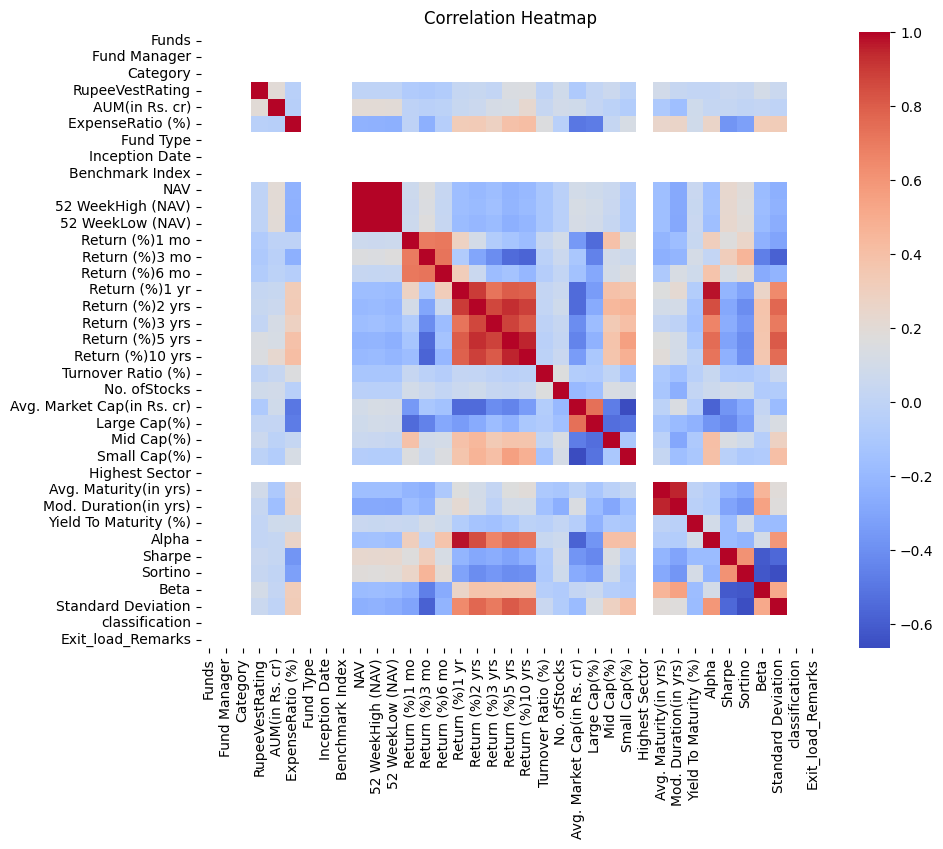

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

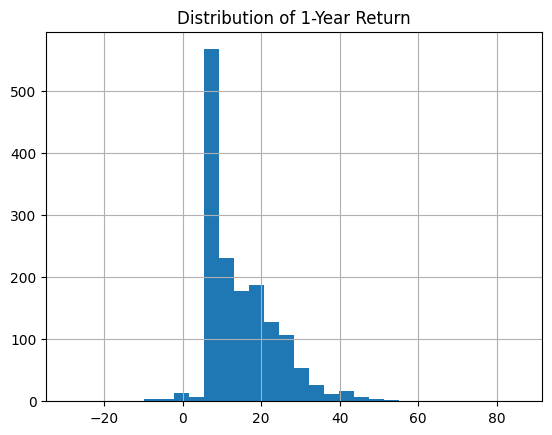

In [ ]:
df_numeric["Return (%)1 yr"].hist(bins=30)
plt.title("Distribution of 1-Year Return")
plt.show()

In [ ]:
X = df_numeric.drop("Return (%)1 yr", axis=1)
y = df_numeric["Return (%)1 yr"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1236, 36)
X_test: (310, 36)


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
import numpy as np

print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test:", np.isnan(X_test).sum())

NaN in X_train: Funds                         1236
Fund Manager                  1236
Category                      1236
RupeeVestRating                774
AUM(in Rs. cr)                   0
ExpenseRatio (%)                75
Fund Type                     1236
Inception Date                1236
Benchmark Index               1236
NAV                              0
52 WeekHigh (NAV)                0
52 WeekLow (NAV)                 0
Return (%)1 mo                   0
Return (%)3 mo                   0
Return (%)6 mo                   0
Return (%)2 yrs                156
Return (%)3 yrs                338
Return (%)5 yrs                511
Return (%)10 yrs               732
Turnover Ratio (%)             176
No. ofStocks                   521
Avg. Market Cap(in Rs. cr)     551
Large Cap(%)                   567
Mid Cap(%)                     555
Small Cap(%)                   702
Highest Sector                1236
Avg. Maturity(in yrs)          721
Mod. Duration(in yrs)          752
Yiel

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Funds' 'Fund Manager' 'Category' 'Fund Type' 'Inception Date'
 'Benchmark Index' 'Highest Sector' 'classification' 'Exit_load_Remarks']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Funds' 'Fund Manager' 'Category' 'Fund Type' 'Inception Date'
 'Benchmark Index' 'Highest Sector' 'classification' 'Exit_load_Remarks']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
print("NaN in X_train after fix:", np.isnan(X_train).sum())

NaN in X_train after fix: 0


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = [r2, mae, rmse]

results_df = pd.DataFrame(results,
                          index=["R2", "MAE", "RMSE"]).T

results_df.sort_values(by="R2", ascending=False)

,R2,MAE,RMSE
Ridge,0.982552,0.641910,1.216643
Linear Regression,0.982468,0.642592,1.219564
Lasso,0.973556,1.030348,1.497810
Decision Tree,0.973549,0.594839,1.498017
Random Forest,0.973309,0.493689,1.504774


In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor()
cv_scores = cross_val_score(rf, X, y, cv=5, scoring="r2")

print("CV Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

CV Scores: [0.99094407 0.96381845 0.99408089 0.9257887  0.99458152]
Average CV R2: 0.973842728084598


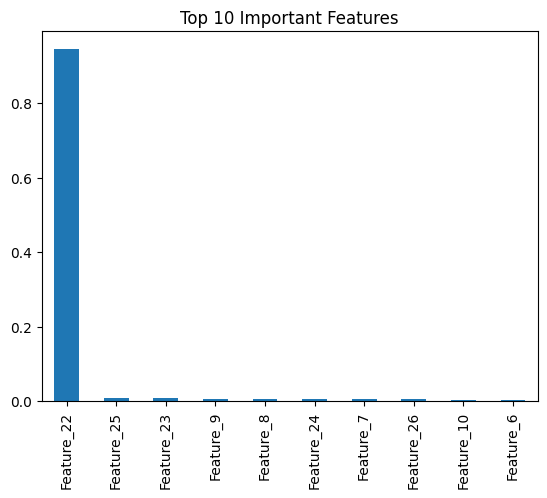

In [ ]:
rf.fit(X_train, y_train)

# Create feature names based on final feature count
final_feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]

importance = pd.Series(rf.feature_importances_, index=final_feature_names)

importance.sort_values(ascending=False).head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf_scaled = RandomForestRegressor(random_state=42)
rf_scaled.fit(X_train_scaled, y_train)

y_pred_rf_scaled = rf_scaled.predict(X_test_scaled)

print("RandomForest R2:", r2_score(y_test, y_pred_rf_scaled))

RandomForest R2: 0.9746042545398641


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost R2: 0.9778548582239068


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 7, 'n_estimators': 200}
Best CV Score: 0.9757055893818688


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("New feature count:", X_train_poly.shape[1])

New feature count: 405


In [ ]:
xgb_poly = XGBRegressor(random_state=42)

xgb_poly.fit(X_train_poly, y_train)

y_pred_poly = xgb_poly.predict(X_test_poly)

print("XGBoost with Polynomial R2:", r2_score(y_test, y_pred_poly))

XGBoost with Polynomial R2: 0.9738298992375762


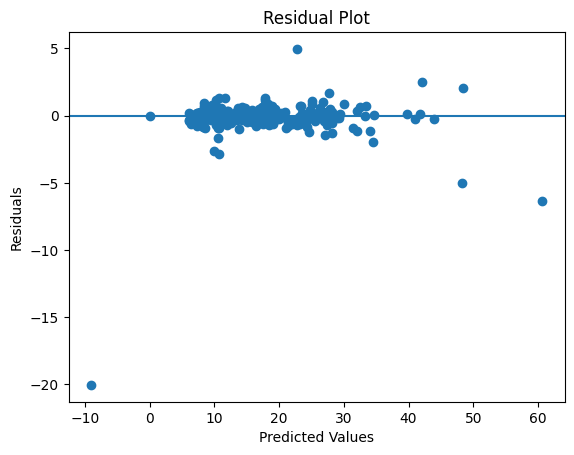

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_xgb

plt.scatter(y_pred_xgb, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

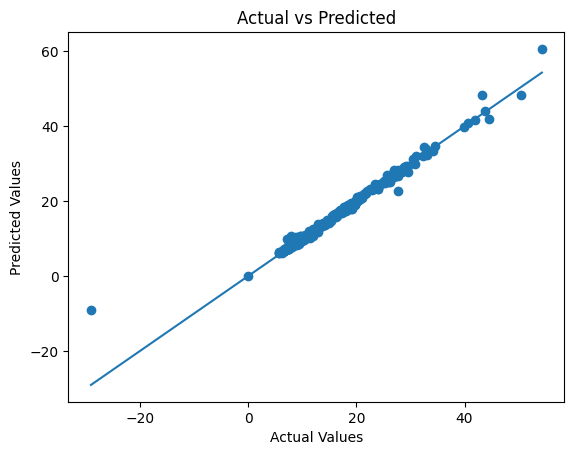

In [ ]:
plt.scatter(y_test, y_pred_xgb)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

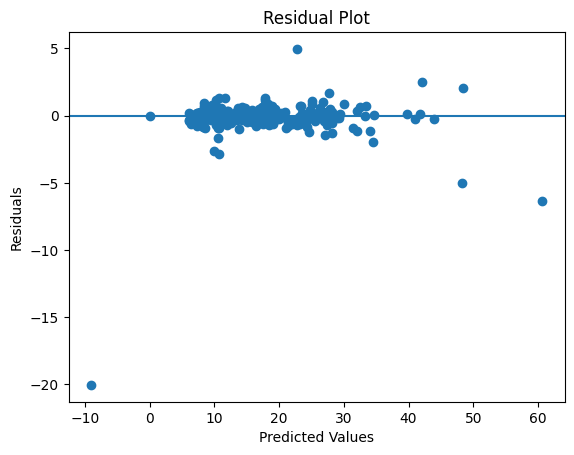

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_xgb

plt.scatter(y_pred_xgb, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
import joblib

joblib.dump(xgb, "mutual_fund_xgb_model.pkl")

['mutual_fund_xgb_model.pkl']

In [ ]:
!pip install shap

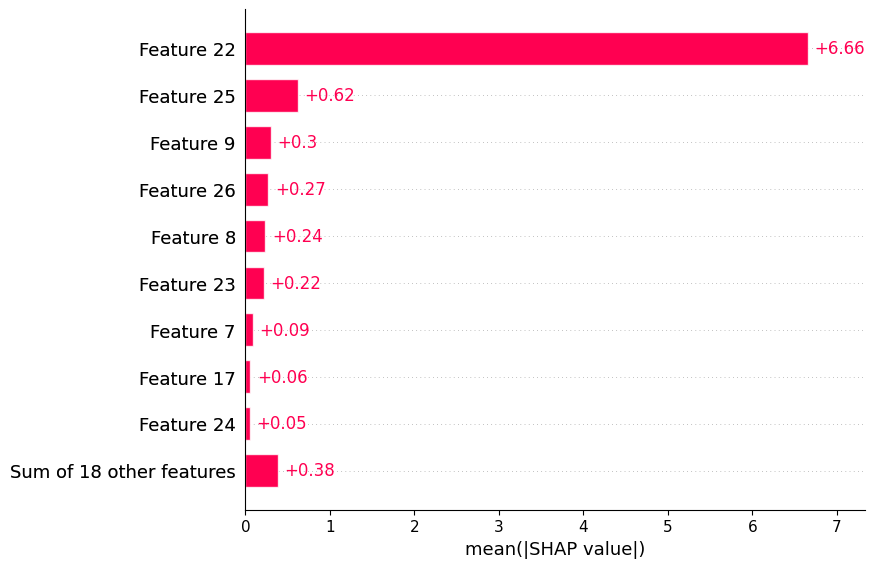

In [ ]:
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_scaled)

shap.plots.bar(shap_values)

# Conclusion

- Random Forest achieved highest R² score.
- Cross validation confirmed consistent performance.
- Key drivers of mutual fund returns were identified through feature importance.
- The model can assist investors in decision making.